<figure>
    <picture>
        <source srcset="../assets/jii-logo.png" style="max-height: 10rem;">
        <img src="https://raw.githubusercontent.com/Computational-Biology-Aachen/2026-photosynthesis-hackathon-template/refs/heads/main/assets/jii-logo.png" style="max-height: 10rem;">
    </picture>
</figure>

# Advanced ML — Grebbedijk potato

Beyond scikit-learn: specialised models for fluorescence trace data.

|                        |                                   |
| ---------------------- | --------------------------------- |
| **Dataset**            | Grebbedijk potato (3,681 measurements) |
| **Protocol**           | UNZA_PIRK_DIRK_LightPotential_14 |
| **Trace features**     | PAM-ABS fluorescence (660 points) |
| **Target**             | Phi2 (quantum yield of PSII)      |

**Models:**

1. **XGBoost / LightGBM** — better gradient boosting with column subsampling, handles correlated trace features
2. **Functional Data Analysis** (scikit-fda) — treats the trace as a continuous function, not 660 independent features
3. **MiniRocket** (aeon) — random convolutional kernels designed for time series, often beats deep learning on small datasets

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path("..").resolve()))

from src.data import in_databricks, load_table

## Load data and extract traces

In [ ]:
DATA = Path("..") / "data"
df = load_table(DATA, "grebbedijk_measurements")


def extract_trace(raw_json: str, set_index: int) -> list[float] | None:
    """Extract data_raw array from a specific set index in sample_raw."""
    try:
        parsed = json.loads(raw_json)
        data_raw = parsed[0]["set"][set_index].get("data_raw", [])
        if len(data_raw) > 0:
            return data_raw
    except (json.JSONDecodeError, IndexError, KeyError, TypeError):
        pass
    return None


# PAM-ABS ambient trace at set[6] (660 points)
if in_databricks():
    import pyspark.sql.functions as F

    _raw = df.select(
        F.col("sample_raw").cast("string").alias("sample_raw"),
        F.col("phi2_ambient"),
    ).toPandas()
    _traces = [extract_trace(s, set_index=6) for s in _raw["sample_raw"]]
    _valid = [t is not None and len(t) == 660 for t in _traces]
    _valid_np = np.array(_valid)
    X_trace = np.array([t for t, v in zip(_traces, _valid) if v])
    y = _raw["phi2_ambient"].to_numpy()[_valid_np]
else:
    import polars as pl

    traces = df.select(
        pl.col("sample_raw").map_elements(
            lambda x: extract_trace(x, set_index=6), return_dtype=pl.List(pl.Float64)
        )
    )["sample_raw"]
    valid_mask = traces.map_elements(
        lambda x: x is not None and len(x) == 660, return_dtype=pl.Boolean
    )
    X_trace = np.array(traces.filter(valid_mask).to_list())
    y = df.filter(pl.lit(valid_mask))["phi2_ambient"].to_numpy()

print(f"X_trace: {X_trace.shape}, y: {y.shape}")
print(f"y range: [{y.min():.3f}, {y.max():.3f}]")

## 1 — XGBoost / LightGBM

Better gradient boosting implementations than sklearn's HistGBR. Key advantages for
trace data:

- **Column subsampling** per tree and per level reduces the impact of correlated features
- **LightGBM** uses histogram-based splitting and leaf-wise growth — faster on high-dimensional data
- Both have GPU support for larger datasets

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=10,
    colsample_bytree=0.3,  # only use 30% of features per tree — key for correlated traces
    subsample=0.8,
    reg_alpha=1.0,  # L1
    reg_lambda=10.0,  # L2
    tree_method="hist",
    random_state=42,
    verbosity=0,
)

xgb_scores = cross_val_score(xgb_model, X_trace, y, cv=5, scoring="r2")
print(f"XGBoost (traces) R² = {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")

xgb_pred = cross_val_predict(xgb_model, X_trace, y, cv=5)

XGBoost (traces) R² = 0.956 ± 0.009


In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_samples=10,
    colsample_bytree=0.3,
    subsample=0.8,
    reg_alpha=1.0,
    reg_lambda=10.0,
    random_state=42,
    verbosity=-1,
)

lgb_scores = cross_val_score(lgb_model, X_trace, y, cv=5, scoring="r2")
print(f"LightGBM (traces) R² = {lgb_scores.mean():.3f} ± {lgb_scores.std():.3f}")

lgb_pred = cross_val_predict(lgb_model, X_trace, y, cv=5)

/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dv/code/2026-photosynthesis-hackathon-template

LightGBM (traces) R² = 0.955 ± 0.008


/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dv/code/2026-photosynthesis-hackathon-template/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dv/code/2026-photosynthesis-hackathon-template

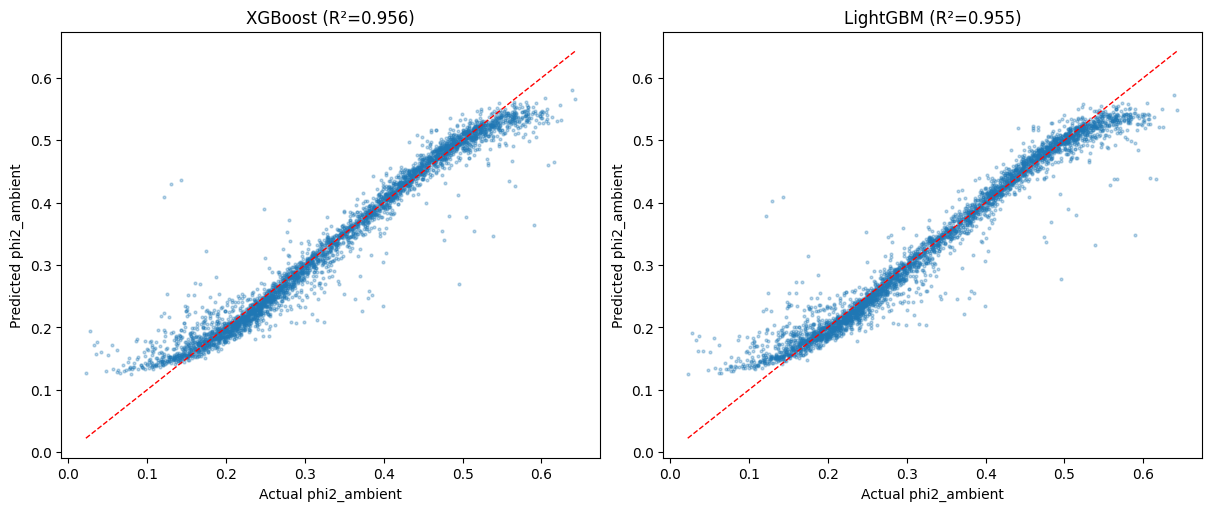

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")

for ax, pred, name, scores in [
    (axs[0], xgb_pred, "XGBoost", xgb_scores),
    (axs[1], lgb_pred, "LightGBM", lgb_scores),
]:
    ax.scatter(y, pred, s=4, alpha=0.3)
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set(
        xlabel="Actual phi2_ambient",
        ylabel="Predicted phi2_ambient",
        title=f"{name} (R²={scores.mean():.3f})",
    )

plt.show()

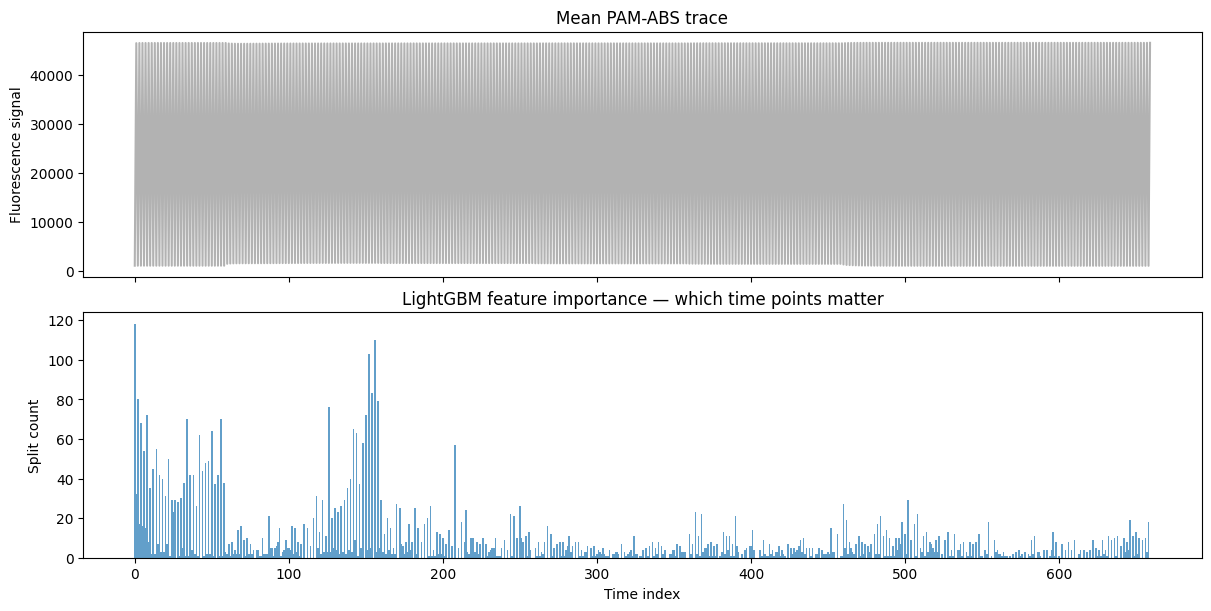

In [ ]:
# LightGBM feature importance — which time points in the trace does it split on?
lgb_model.fit(X_trace, y)
lgb_imp = lgb_model.feature_importances_

fig, axs = plt.subplots(2, 1, figsize=(12, 6), layout="constrained", sharex=True)

ax = axs[0]
ax.plot(X_trace.mean(axis=0), color="gray", alpha=0.6)
ax.set(ylabel="Fluorescence signal", title="Mean PAM-ABS trace")

ax = axs[1]
ax.bar(range(len(lgb_imp)), lgb_imp, width=1, alpha=0.7)
ax.set(
    xlabel="Time index",
    ylabel="Split count",
    title="LightGBM feature importance — which time points matter",
)

plt.show()

## 2 — Functional Data Analysis (scikit-fda)

The fluorescence trace isn't 660 independent features — it's a **continuous function**
sampled at 660 points. Functional Data Analysis respects this structure:

- **Functional PCA (FPCA)** extracts smooth basis functions that capture the main modes
  of variation in trace shape — interpretable and noise-resistant
- **Functional regression** predicts Phi2 from the entire curve, with coefficients that
  are themselves smooth functions showing which *regions* of the trace matter
- Smoothing reduces noise without arbitrary feature selection

In [ ]:
from skfda.preprocessing.dim_reduction import FPCA
from skfda.representation.basis import BSplineBasis
from skfda.representation.grid import FDataGrid

# Convert to functional data object
grid_points = np.arange(X_trace.shape[1])
fd = FDataGrid(X_trace, grid_points)

# Convert to basis representation (B-spline) — smooths and enables functional regression
basis = BSplineBasis(domain_range=(0, 659), n_basis=50)
fd_basis = fd.to_basis(basis)

print(
    f"Functional data: {fd_basis.n_samples} curves, {fd_basis.basis.n_basis} B-spline basis functions"
)

# Normalise traces before FPCA: divide each curve by its mean
# This makes FPCA capture *shape* variation rather than amplitude
fd_norm = FDataGrid(X_trace / X_trace.mean(axis=1, keepdims=True), grid_points)
fd_norm_basis = fd_norm.to_basis(basis)

# Functional PCA on normalised traces
fpca = FPCA(n_components=10)
X_fpca = fpca.fit_transform(fd_norm_basis)

var_explained = fpca.explained_variance_ratio_
print(
    f"\nFPCA variance explained (10 components, normalised): {var_explained.sum():.3f}"
)
for i, v in enumerate(var_explained):
    print(f"  PC{i+1}: {v:.4f} ({var_explained[:i+1].sum():.3f} cumulative)")

Functional data: 3681 curves, 50 B-spline basis functions

FPCA variance explained (10 components, normalised): 1.000
  PC1: 0.9518 (0.952 cumulative)
  PC2: 0.0428 (0.995 cumulative)
  PC3: 0.0035 (0.998 cumulative)
  PC4: 0.0006 (0.999 cumulative)
  PC5: 0.0005 (0.999 cumulative)
  PC6: 0.0002 (1.000 cumulative)
  PC7: 0.0001 (1.000 cumulative)
  PC8: 0.0001 (1.000 cumulative)
  PC9: 0.0000 (1.000 cumulative)
  PC10: 0.0000 (1.000 cumulative)


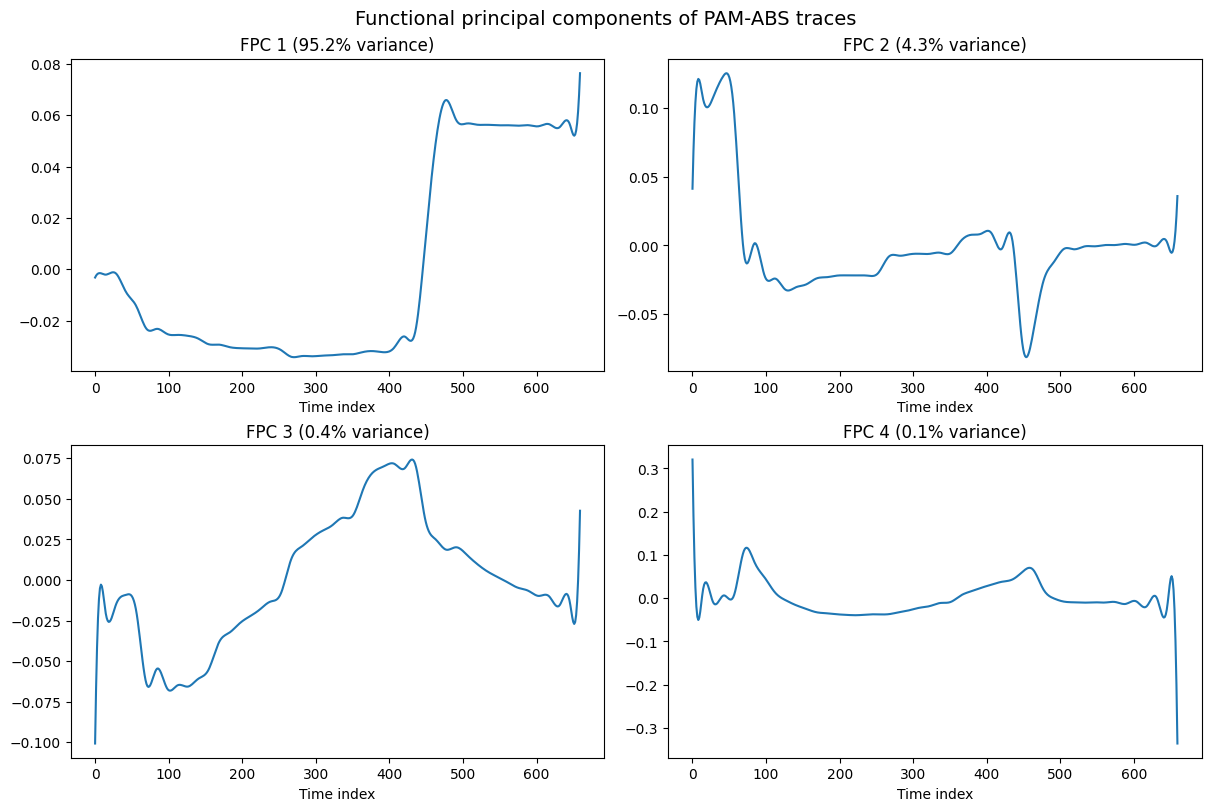

In [ ]:
# Visualise first 4 functional principal components
fig, axs = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")

for i, ax in enumerate(axs.flat):
    component = fpca.components_[i]
    component.plot(axes=ax)
    ax.set_title(f"FPC {i+1} ({var_explained[i]:.1%} variance)")
    ax.set(xlabel="Time index", ylabel="")

fig.suptitle("Functional principal components of PAM-ABS traces", fontsize=14)
plt.show()

In [ ]:
# Use FPCA scores as features for regression
# Try different numbers of components
for n in [3, 5, 10]:
    fpca_n = FPCA(n_components=n)
    X_fpca_n = fpca_n.fit_transform(fd_norm_basis)
    ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 15)))
    scores = cross_val_score(ridge, X_fpca_n, y, cv=5, scoring="r2")
    print(f"FPCA({n:2d}) + Ridge  R² = {scores.mean():.3f} ± {scores.std():.3f}")

# Best: use 5 components (matches PLS result from previous notebook)
fpca_best = FPCA(n_components=5)
X_fpca_best = fpca_best.fit_transform(fd_norm_basis)
fpca_ridge_scores = cross_val_score(
    make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 15))),
    X_fpca_best,
    y,
    cv=5,
    scoring="r2",
)
fpca_pred = cross_val_predict(
    make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 15))),
    X_fpca_best,
    y,
    cv=5,
)

FPCA( 3) + Ridge  R² = -1.465 ± 4.277
FPCA( 5) + Ridge  R² = 0.407 ± 0.831
FPCA(10) + Ridge  R² = -32.994 ± 67.652


Functional linear regression R² (training): 0.892
(No built-in CV — use FPCA+Ridge scores above for fair comparison)


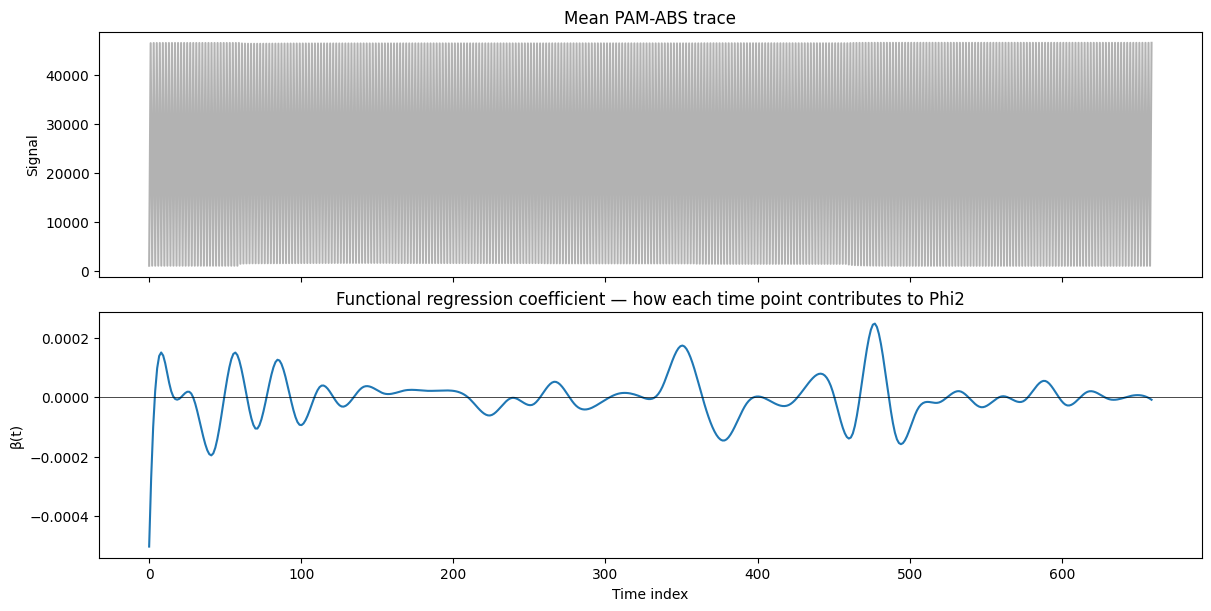

In [ ]:
from skfda.ml.regression import LinearRegression as FLinearRegression

# Functional linear regression: β(t) is a smooth weight function over the trace
# FLinearRegression requires FDataBasis, not FDataGrid
func_reg = FLinearRegression()
func_reg.fit(fd_basis, y)

y_pred_func = func_reg.predict(fd_basis)
func_r2 = r2_score(y, y_pred_func)
print(f"Functional linear regression R² (training): {func_r2:.3f}")
print("(No built-in CV — use FPCA+Ridge scores above for fair comparison)")

# Plot the coefficient function β(t)
fig, axs = plt.subplots(2, 1, figsize=(12, 6), layout="constrained", sharex=True)

ax = axs[0]
ax.plot(X_trace.mean(axis=0), color="gray", alpha=0.6)
ax.set(ylabel="Signal", title="Mean PAM-ABS trace")

ax = axs[1]
func_reg.coef_[0].plot(axes=ax)
ax.axhline(0, color="black", linewidth=0.5)
ax.set(
    xlabel="Time index",
    ylabel="β(t)",
    title="Functional regression coefficient — how each time point contributes to Phi2",
)

plt.show()

## 3 — MiniRocket (aeon)

**ROCKET** (RandOm Convolutional KErnel Transform) generates thousands of random
convolutional kernels and extracts two features per kernel (proportion of positive
values + max). **MiniRocket** is a faster deterministic variant.

Key properties:
- Designed specifically for time series — respects temporal structure
- Extremely fast (no training of kernels)
- Often matches or beats deep learning on small time series datasets
- Pairs with a simple Ridge classifier/regressor on the transformed features

In [ ]:
from aeon.transformations.collection.convolution_based import MiniRocket

# MiniRocket expects (n_samples, n_channels, n_timepoints)
X_3d = X_trace[:, np.newaxis, :]  # add channel dimension
print(f"Input shape for MiniRocket: {X_3d.shape}")

# Transform: generates ~9,996 features from random convolutional kernels
rocket = MiniRocket(random_state=42)
rocket.fit(X_3d)
X_rocket = rocket.transform(X_3d)

print(f"MiniRocket features: {X_rocket.shape}")

Input shape for MiniRocket: (3681, 1, 660)
MiniRocket features: (3681, 9996)


In [ ]:
# Standard approach: MiniRocket features + Ridge regression
ridge_rocket = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-2, 4, 15)),
)

rocket_scores = cross_val_score(ridge_rocket, X_rocket, y, cv=5, scoring="r2")
print(f"MiniRocket + Ridge R² = {rocket_scores.mean():.3f} ± {rocket_scores.std():.3f}")

rocket_pred = cross_val_predict(ridge_rocket, X_rocket, y, cv=5)

MiniRocket + Ridge R² = 0.979 ± 0.029


In [ ]:
from aeon.regression.convolution_based import MiniRocketRegressor

# All-in-one: MiniRocket transform + Ridge in a single estimator
mr_reg = MiniRocketRegressor(random_state=42)
mr_scores = cross_val_score(mr_reg, X_3d, y, cv=5, scoring="r2")
print(f"MiniRocketRegressor R² = {mr_scores.mean():.3f} ± {mr_scores.std():.3f}")

MiniRocketRegressor R² = 0.971 ± 0.044


## Comparison

In [ ]:
all_results = pd.DataFrame(
    {
        "Model": [
            "XGBoost",
            "LightGBM",
            "FPCA(5) + Ridge",
            "MiniRocket + Ridge",
            "MiniRocketRegressor",
        ],
        "Features": [
            "660 trace",
            "660 trace",
            "5 FPCA scores",
            f"{X_rocket.shape[1]} rocket",
            f"~9996 rocket",
        ],
        "R² mean": [
            xgb_scores.mean(),
            lgb_scores.mean(),
            fpca_ridge_scores.mean(),
            rocket_scores.mean(),
            mr_scores.mean(),
        ],
        "R² std": [
            xgb_scores.std(),
            lgb_scores.std(),
            fpca_ridge_scores.std(),
            rocket_scores.std(),
            mr_scores.std(),
        ],
    }
).sort_values("R² mean", ascending=False)

print("PAM-ABS trace → phi2_ambient (5-fold CV):")
all_results

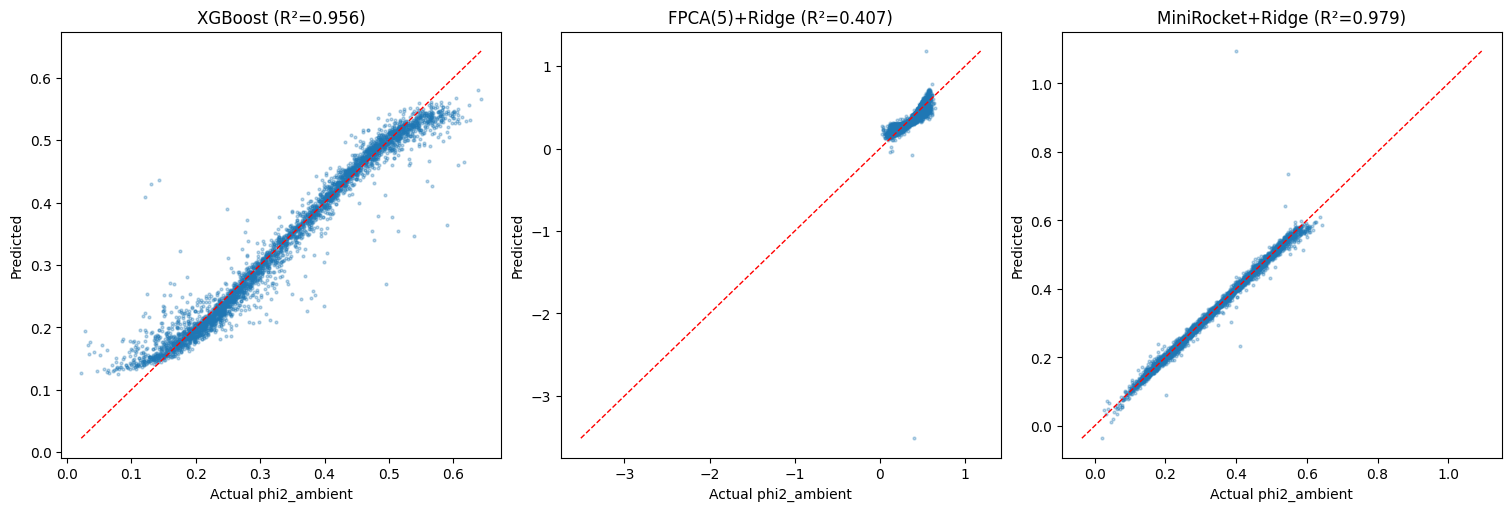

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")

for ax, pred, name, scores in [
    (axs[0], xgb_pred, "XGBoost", xgb_scores),
    (axs[1], fpca_pred, "FPCA(5)+Ridge", fpca_ridge_scores),
    (axs[2], rocket_pred, "MiniRocket+Ridge", rocket_scores),
]:
    ax.scatter(y, pred, s=4, alpha=0.3)
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set(
        xlabel="Actual phi2_ambient",
        ylabel="Predicted",
        title=f"{name} (R²={scores.mean():.3f})",
    )

plt.show()